<a href="https://colab.research.google.com/github/LakshmiAhala/DataScience/blob/main/DS_FinalProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of Padma Awards (and Awardees)

In [ ]:
#@title Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Formation of the Master excel

In [ ]:
#@title Combining all the excel sheets to one Master dataframe

# Loading the Excel file
excel_file = pd.ExcelFile('padma_awards.xlsx')

# Getting the names of all the sheets
sheet_names = excel_file.sheet_names

# Creating an empty list to store DataFrames
all_data = []

# Looping through each sheet, read it into a DataFrame, and append it to the list
for sheet_name in sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet_name)
    df['Year'] = sheet_name  # Add a column with the sheet name
    all_data.append(df)

# Concatenating all DataFrames in the list into a single DataFrame
padmaawards_df = pd.concat(all_data, ignore_index=True)
print('Master dataframe has successfully been created.')
display(padmaawards_df)


Master dataframe has successfully been created.


,Category,SN,Name,Field,State / Country,Year
0,Padmavibhushan,1,Shri Duvvur Nageshwar Reddy,Medicine,Telangana,2025
1,Padmavibhushan,2,Justice (Retd.) Shri Jagdish Singh Khehar,Public Affairs,Chandigarh,2025
2,Padmavibhushan,3,Smt. Kumudini Rajnikant Lakhia,Art,Gujarat,2025
3,Padmavibhushan,4,Shri Lakshminarayana Subramaniam,Art,Karnataka,2025
4,Padmavibhushan,5,Shri M. T. Vasudevan Nair\n(Posthumous),Literature and Education,Kerala,2025
...,...,...,...,...,...,...
1263,PadmaShri,100,Dr. Raghu Rama Pillarisetti\n(NRI/PIO),Medicine,United States of America,2015
1264,PadmaShri,101,Dr. Saumitra Rawat (NRI/PIO),Medicine,United Kingdom,2015
1265,PadmaShri,102,Prof. Annette Schmiedchen (Foreigner),Literature & Education,Germany,2015
1266,PadmaShri,103,Late Shri Pran Kumar Sharma alias Pran (Po...,Art,Delhi,2015


# Insights / Questions



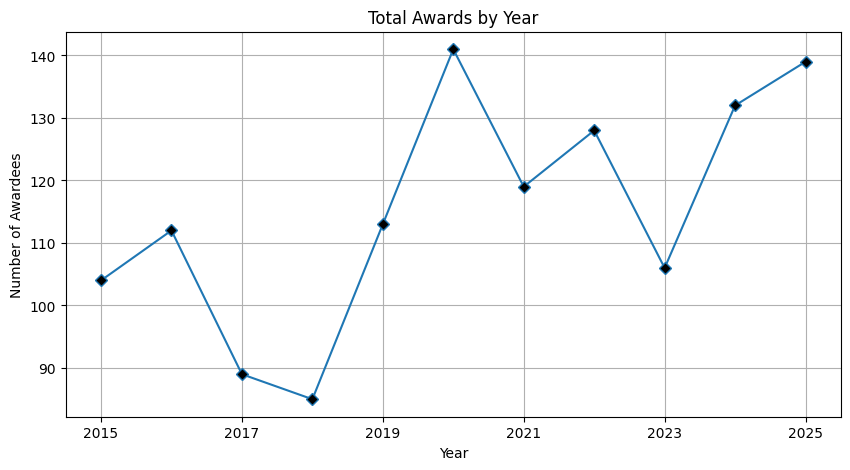

In [ ]:
#@title 1) What are the Total Awards by Year?

# Grouping by Year and Count Awards
awards_by_year = padmaawards_df.groupby('Year')['Category'].count()

# Plotting a line graph
awards_by_year.plot(x='Year', y='Num of Awards', kind='line', marker='D',
markerfacecolor='black', markersize=6, figsize=(10, 5))
plt.title('Total Awards by Year')
plt.xlabel('Year')
plt.ylabel('Number of Awardees')
plt.grid(True)
plt.show()


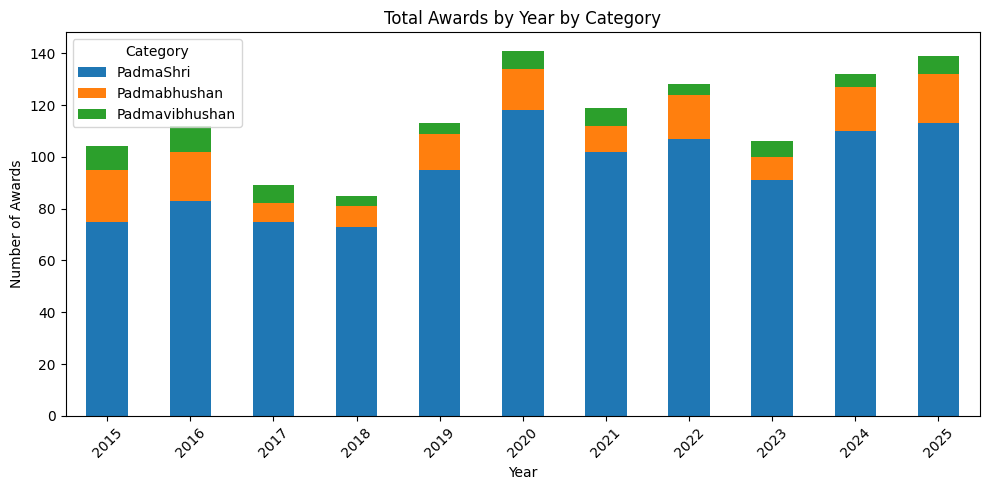

In [ ]:
#@title 2) What are the total Awards by Year & what are their Award Types?

# Creating a cross-tabulation of Year and Category, counting occurrences
awards_by_year_category = pd.crosstab(padmaawards_df['Year'],
                                      padmaawards_df['Category'])

# Plotting the stacked bar chart
awards_by_year_category.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Total Awards by Year by Category')
plt.xlabel('Year')
plt.ylabel('Number of Awards')
plt.legend(title='Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


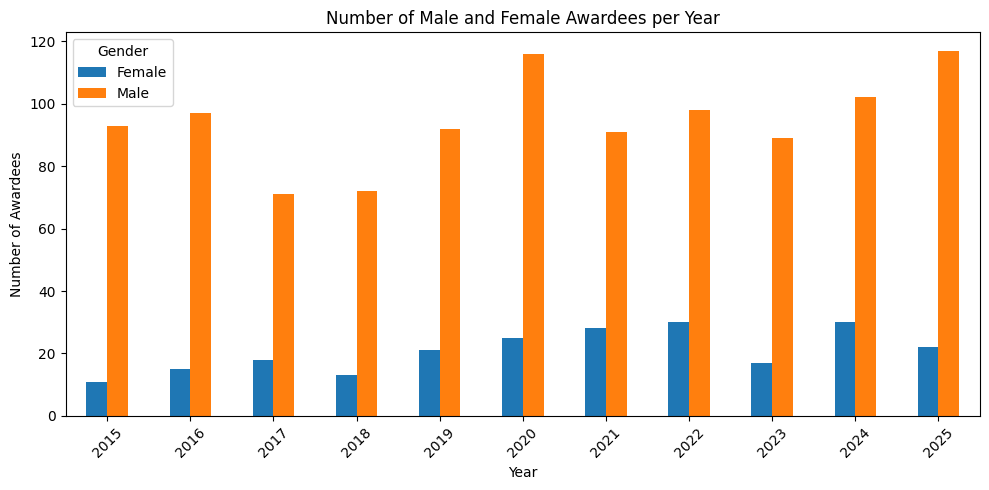

In [ ]:
#@title 3) How many male and female awardees by year?

# Creating a new coloumn with the Gender of the awardees
padmaawards_df['Gender'] = np.where(
    padmaawards_df['Name'].str.contains("Smt|Ms.", na=False, regex=True),
    'Female', 'Male')

# Creating a cross-tabulation of Year and Gender, counting occurrences
gender_by_year = pd.crosstab(padmaawards_df['Year'], padmaawards_df['Gender'])

# Plotting the bar chart
gender_by_year.plot(kind='bar', figsize=(10, 5))
plt.title('Number of Male and Female Awardees per Year')
plt.xlabel('Year')
plt.ylabel('Number of Awardees')
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


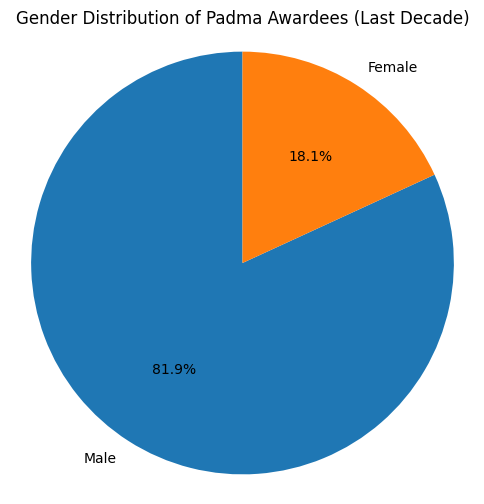

In [ ]:
#@title 3.1) Total distribution of male and female awardees

# Calculating the total number of male and female awardees
gender_counts_last_decade = padmaawards_df['Gender'].value_counts()

# Creating the pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_counts_last_decade, labels=gender_counts_last_decade.index,
        autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution of Padma Awardees (Last Decade)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

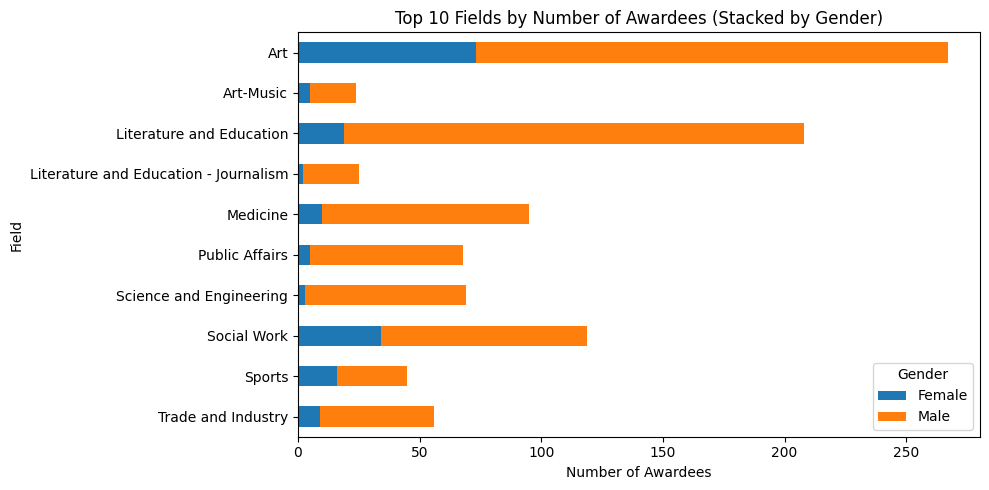

In [ ]:
#@title 4) Which are the top 10 fields with the most number of awardees?

# Cleaning the 'Field' column
padmaawards_df['Field'] = padmaawards_df['Field'].apply(lambda x: re.sub('&', 'and', str(x)))

# Grouping by Field and Gender, then counting occurrences
field_gender_counts = padmaawards_df.groupby(['Field', 'Gender'])['Name'].count().reset_index()

# Getting the top 10 fields overall
top_10_fields = padmaawards_df['Field'].value_counts().head(10).index

# Filtering the data for the top 10 fields
filtered_data = field_gender_counts[field_gender_counts['Field'].isin(top_10_fields)]

# Pivoting the data for the stacked bar chart and sorting in descending order
pivot_data = filtered_data.pivot(index='Field', columns='Gender', values='Name').fillna(0)

# Creating the stacked horizontal bar chart
pivot_data.plot(kind='barh', stacked=True, figsize=(10, 5))
plt.xlabel('Number of Awardees')
plt.ylabel('Field')
plt.title('Top 10 Fields by Number of Awardees (Stacked by Gender)')
plt.legend(title='Gender')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

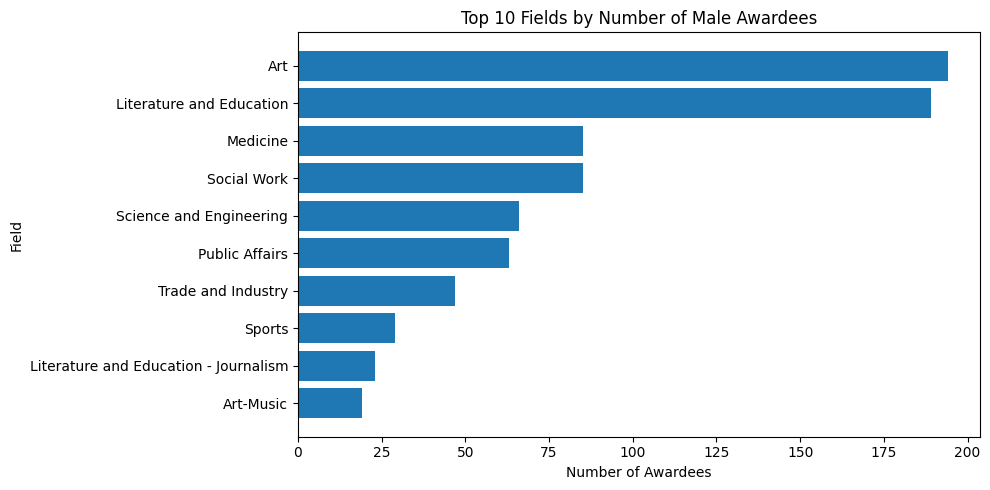

In [ ]:
#@title 5) Which are the top 10 fields with the most number of male awardees?

# Filtering the DataFrame to include only male awardees
male_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Male']

# Calculating the number of male awardees for each field
field_counts_male = male_awardees_df['Field'].value_counts()

# Getting the top 10 fields for male awardees
top_10_fields_male = field_counts_male.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_fields_male.index, top_10_fields_male.values)
plt.xlabel('Number of Awardees')
plt.ylabel('Field')
plt.title('Top 10 Fields by Number of Male Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


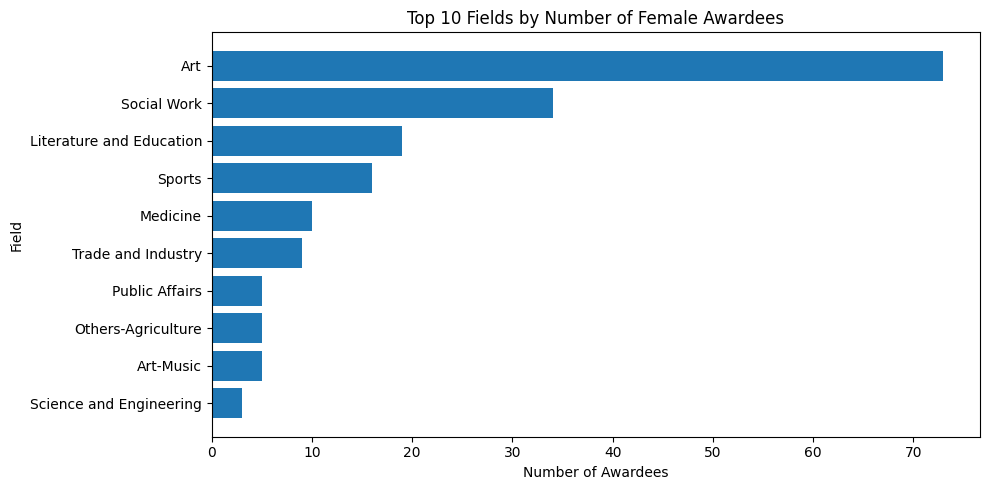

In [ ]:
#@title 6) Which are the top 10 fields with the most number of female awardees?

# Filtering the DataFrame to include only female awardees
female_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Female']

# Calculating the number of female awardees for each field
field_counts_female = female_awardees_df['Field'].value_counts()

# Getting the top 10 fields for female awardees
top_10_fields_female = field_counts_female.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_fields_female.index, top_10_fields_female.values)
plt.xlabel('Number of Awardees')
plt.ylabel('Field')
plt.title('Top 10 Fields by Number of Female Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


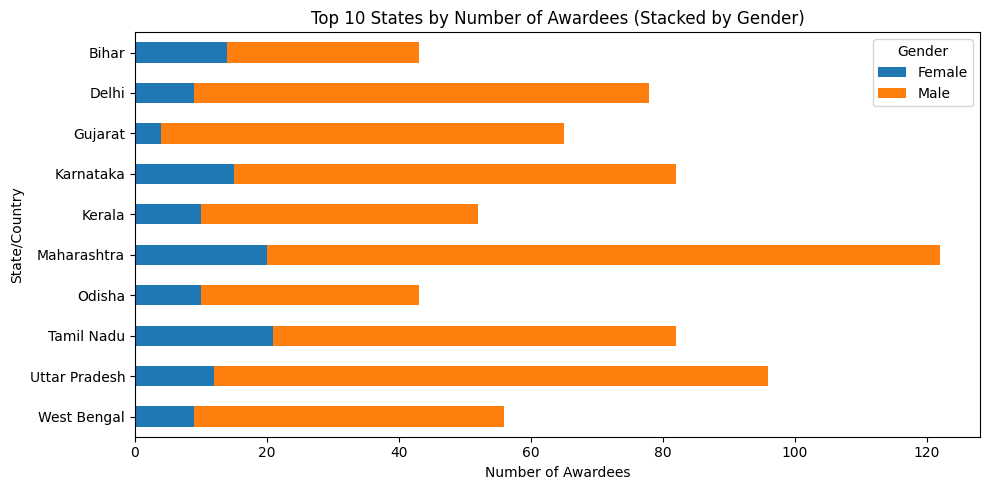

In [ ]:
#@title 7) Which are the top 10 States with most number of awardees?

# Cleaning the 'State / Country' column
padmaawards_df['State / Country'] = padmaawards_df['State / Country'].apply(lambda x: re.sub('&', 'and', str(x)))

# Grouping by State / Country and Gender, then counting occurrences
state_gender_counts = padmaawards_df.groupby(['State / Country', 'Gender'])['Name'].count().reset_index()

# Getting the top 10 states overall
top_10_states = padmaawards_df['State / Country'].value_counts().head(10).index

# Filtering the data for the top 10 states
filtered_data = state_gender_counts[state_gender_counts['State / Country'].isin(top_10_states)]

# Pivoting the data for the stacked bar chart and sorting in descending order
pivot_data = filtered_data.pivot(index='State / Country', columns='Gender', values='Name').fillna(0)

# Creating the stacked horizontal bar chart
pivot_data.plot(kind='barh', stacked=True, figsize=(10, 5))
plt.xlabel('Number of Awardees')
plt.ylabel('State/Country')
plt.title('Top 10 States by Number of Awardees (Stacked by Gender)')
plt.legend(title='Gender')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

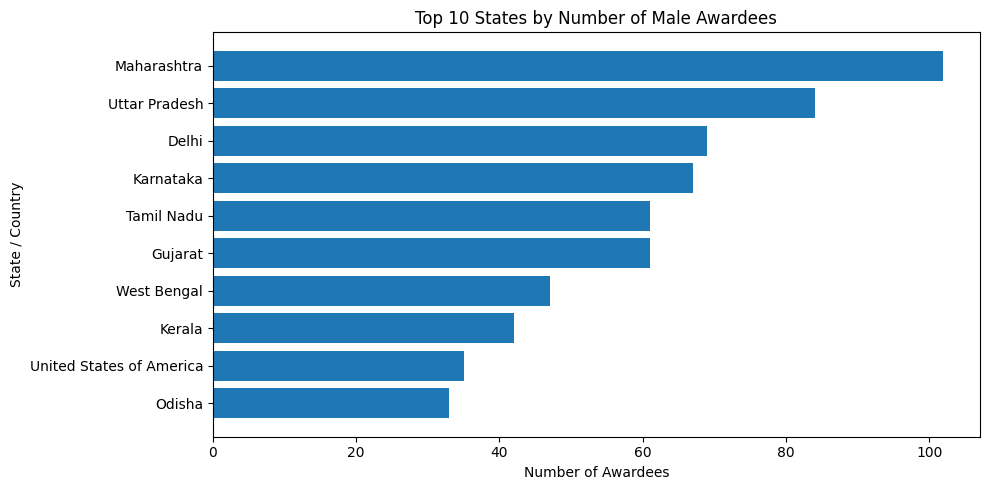

In [ ]:
#@title 8) Which are the top 10 States with the most number of male awardees?

# Filtering the DataFrame to include only male awardees
male_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Male']

# Calculating the number of male awardees for each state
state_counts_male = male_awardees_df['State / Country'].value_counts()

# Getting the top 10 states for male awardees
top_10_states_male = state_counts_male.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_states_male.index, top_10_states_male.values)
plt.xlabel('Number of Awardees')
plt.ylabel('State / Country')
plt.title('Top 10 States by Number of Male Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


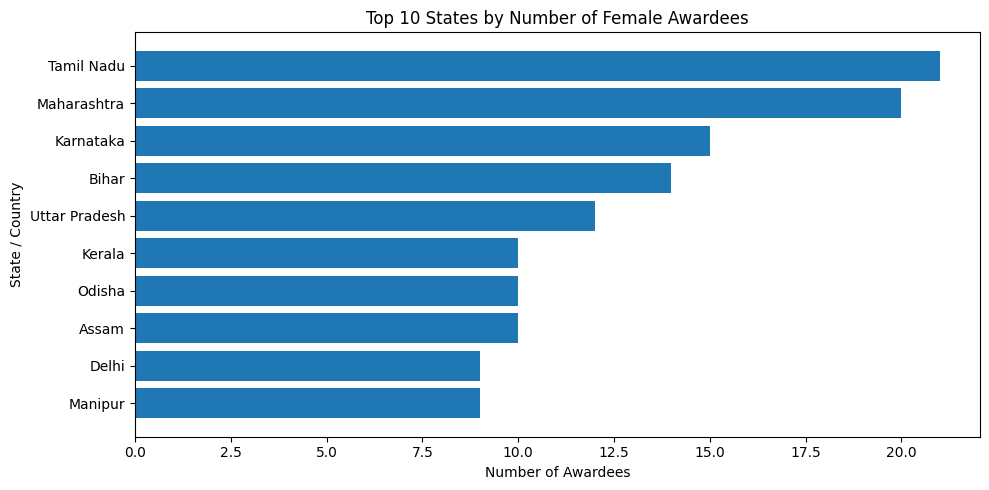

In [ ]:
#@title 9) Which are the top 10 States with the most number of female awardees?

# Filtering the DataFrame to include only female awardees
female_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Female']

# Calculating the number of female awardees for each state
state_counts_female = female_awardees_df['State / Country'].value_counts()

# Getting the top 10 states for female awardees
top_10_states_female = state_counts_female.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_states_female.index, top_10_states_female.values)
plt.xlabel('Number of Awardees')
plt.ylabel('State / Country')
plt.title('Top 10 States by Number of Female Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
#@title 10) How many foreigners have received Padma Awards? Who are they?

# Creating a list of all the featured Indian States and UTs (and their diff. spellings)
indian_states_uts = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa',
    'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand', 'Karnataka', 'Kerala',
    'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
    'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
    'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Andaman & Nicobar',
    'Chandigarh', 'Daman & Diu', 'Delhi', 'Ladakh', 'Lakshadweep', 'Puducherry',
    'Andaman & Nicobar', 'Jammu & Kashmir', 'NCT Delhi']


# Filtering the data to get only the foreigners
foreigners_df = padmaawards_df[~padmaawards_df['State / Country'].isin(indian_states_uts)]
num_foreigners = len(foreigners_df) - 1
print('The names of the foreigners who have recieved Padma Awards: ')
display(foreigners_df)
print(f"Total Number of foreigners who received Padma Awards: {num_foreigners}")


The names of the foreigners who have recieved Padma Awards: 


,Category,SN,Name,Field,State / Country,Year,Gender
5,Padmavibhushan,6,Shri Osamu Suzuki\n(Posthumous),Trade and Industry,Japan,2025,Male
25,Padmabhushan,26,Shri Vinod Dham,Science and Engineering,United States of America,2025,Male
28,PadmaShri,29,Shri Ajay V Bhatt,Science and Engineering,United States of America,2025,Male
33,PadmaShri,34,Shri Arvind Sharma,Literature and Education,Canada,2025,Male
50,PadmaShri,51,Shri Chetan E Chitnis,Science and Engineering,France,2025,Male
...,...,...,...,...,...,...,...
1261,PadmaShri,98,Ms. Tripti Mukherjee\n(NRI/PIO),Art,United States of America,2015,Female
1262,PadmaShri,99,Dr. Dattatreyudu Nori\n(NRI/PIO),Medicine,United States of America,2015,Male
1263,PadmaShri,100,Dr. Raghu Rama Pillarisetti\n(NRI/PIO),Medicine,United States of America,2015,Male
1264,PadmaShri,101,Dr. Saumitra Rawat (NRI/PIO),Medicine,United Kingdom,2015,Male


Total Number of foreigners who received Padma Awards: 143


In [ ]:
#@title 11) Which countries are those foreigners from?

# Getting all the unique foreign countries
countries = foreigners_df['State / Country'].unique()
print('The countries the foreigners from are: ')
print(countries)


The countries the foreigners from are: 
['Japan' 'United States of America' 'Canada' 'France' 'Jammu and Kashmir'
 'Brazil' 'Kuwait' 'Taiwan' 'Bangladesh' 'Andaman and Nicobar'
 'Papua New Guinea' 'Mexico' 'Daman and Diu' 'Poland' 'United Kingdom'
 'Ireland' 'Thailand' 'Russia' 'Indonesia' 'Greece' 'Spain' 'Mauritius'
 'Sri Lanka' 'Afghanistan' 'Djibouti' 'South Africa' 'Germany'
 'Philippines' 'Malaysia' 'Laos' 'Singapore' 'Cambodia' 'Saudi Arabia'
 'Myanmar' 'Brunei' 'Tajikistan' 'Nepal' 'Vietnam' 'China' 'Serbia'
 'United Arab Emirates' 'Portugal']


<ipython-input-15-62c029463167>:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  posthumous_mask = padmaawards_df['Name'].str.contains("(Posthumous)", na=False)


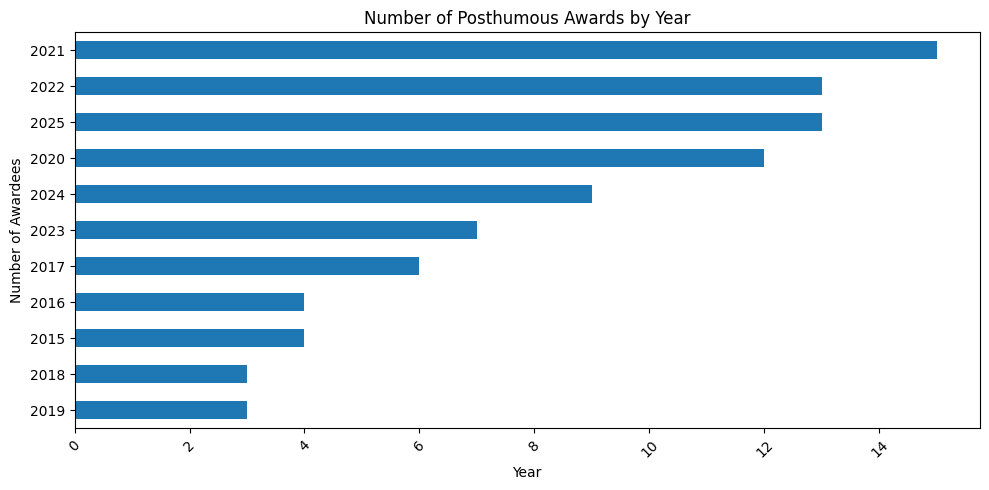

In [ ]:
#@title 12) How many awards were given posthumously?

# Creating a boolean mask where True indicates "(Posthumous)" is in the 'Name'
posthumous_mask = padmaawards_df['Name'].str.contains("(Posthumous)", na=False)

# Applying the mask to the DataFrame to get the rows with "(Posthumous)"
posthumous_df = padmaawards_df[posthumous_mask]

# Creating the horizontal bar graph
posthumous_by_year = posthumous_df.groupby('Year')['Name'].count().sort_values(ascending=False)
posthumous_by_year.plot(kind='barh', figsize=(10, 5))
plt.title('Number of Posthumous Awards by Year')
plt.xlabel('Year')
plt.ylabel('Number of Awardees')
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


<ipython-input-20-4b2fcd7588b3>:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  duo_mask = padmaawards_df['Name'].str.contains("(Duo)", na=False)


,Category,SN,Name,Field,State / Country,Year,Gender
65,PadmaShri,66,Shri Hugh and Colleen Gantzer\n(Posthumous) (D...,Literature and Education - Journalism,Uttarakhand,2025,Male
215,PadmaShri,77,Shri Ali Mohammed & Shri Ghani Mohammed*\n(Duo),Art,Rajasthan,2024,Male
234,PadmaShri,96,Ms. Shanti Devi Paswan & Shri Shivan Paswan*\n...,Art,Bihar,2024,Female
301,PadmaShri,31,Shri Ahmed Hussain & Shri Mohd\nHussain *(Duo),Art,Rajasthan,2023,Male
330,PadmaShri,60,Shri Ramesh Parmar & Ms. Shanti\nParmar *(Duo),Art,Madhya Pradesh,2023,Female
349,PadmaShri,79,Shri Vadivel Gopal & Shri Masi\nSadaiyan *(Duo),Social Work,Tamil Nadu,2023,Male
386,Padmabhushan,10,Shri Krishna Ella and Smt. Suchitra Ella* (Duo),Trade and Industry,Telangana,2022,Female
402,PadmaShri,26,Ms. Kamalini Asthana and Ms. Nalini Asthana* (...,Art,Uttar Pradesh,2022,Female
558,PadmaShri,54,Shri Maheshbhai & Shri Nareshbhai Kanodia (Duo...,Art,Gujarat,2021,Male
667,PadmaShri,44,Ms. Lalitha & Ms. Saroja\nChidamba...,Art,Tamil Nadu,2020,Female




Analyzing the Duos by their field



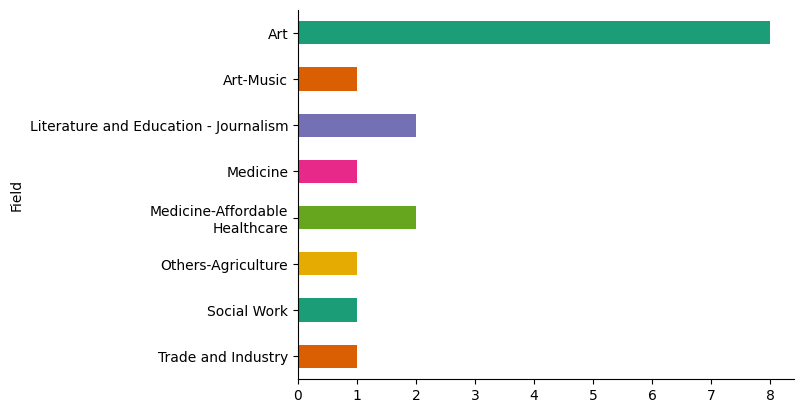

In [ ]:
#@title 13) How many duos have recieved Padma awards by field?

# Creating a boolean mask where True indicates "(Duo)" is in the 'Name'
duo_mask = padmaawards_df['Name'].str.contains("(Duo)", na=False)

# Applying the mask to the DataFrame to get the rows with "(Duo)"
duo_df = padmaawards_df[duo_mask]
display(duo_df)

# Creating a horizontal bar graph by the Field of the duos
print('\n\nAnalyzing the Duos by their field\n')
duo_df.groupby('Field').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.gca().invert_yaxis()


In [ ]:
#@title 14) How many people have got multiple Padma awards?

# Grouping by 'Name' and count occurrences
name_counts = padmaawards_df.groupby('Name')['Name'].count()

# Filtering for counts greater than 1 (indicating multiple awards)
multiple_awards_df = name_counts[name_counts > 1]

# Getting the number of people with multiple awards
num_multiple_awards = len(multiple_awards_df)

# Printing the result
print(f"Number of people with multiple Padma awards: {num_multiple_awards}")

# Displaying the names and counts
print("\nPeople with multiple Padma awards:")
display(multiple_awards_df)


Number of people with multiple Padma awards: 2

People with multiple Padma awards:


,Name
Name,
Ms. P. V. Sindhu,2
Shri Mahesh Sharma,2


The years in the Light Blue tinge are the Election years.
The years in the Green tinge are the normal years.


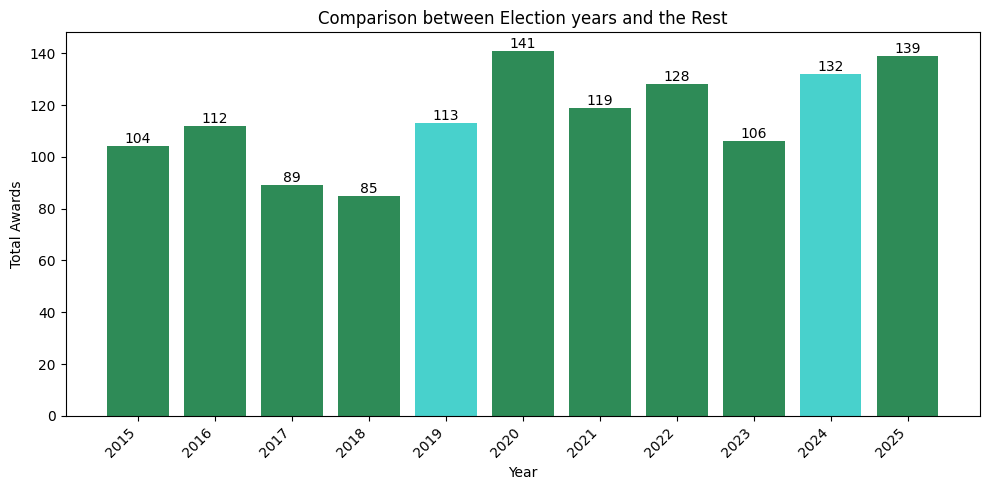

In [ ]:
#@title 15) Compare Election year(s) awards with the rest (TBD: Add legend)

# Grouping data by year and count the number of awards
awards_by_year = padmaawards_df.groupby('Year')['Name'].count().reset_index()
colors_election = ['seagreen', 'seagreen', 'seagreen', 'seagreen', 'mediumturquoise',
                   'seagreen', 'seagreen', 'seagreen', 'seagreen', 'mediumturquoise', 'seagreen']
print('The years in the Light Blue tinge are the Election years.')
print('The years in the Green tinge are the normal years.')

# Creating the bar graph
plt.figure(figsize=(10, 5))  # Adjust figure size as needed
plt.bar(awards_by_year['Year'], awards_by_year['Name'], color=colors_election)
plt.xlabel("Year")
plt.ylabel("Total Awards")
plt.title("Comparison between Election years and the Rest")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Getting the total number of awardees written above each bar
ax = plt.gca()

for patch in ax.patches:
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.text(x, height, f'{height:.0f}', ha='center', va='bottom')
plt.show()


The years in the Green tinge are the Covid affected years.
The years in the Blue tinge are the normal years.


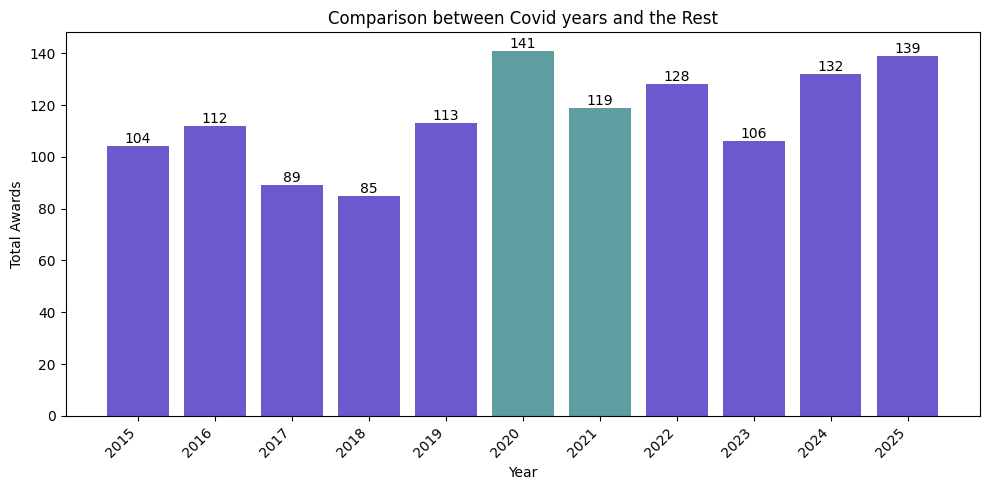

In [ ]:
#@title 16) Compare Covid year(s) awards with the rest. (TBD: Add legend)

# Grouping data by year and count the number of awards
awards_by_year = padmaawards_df.groupby('Year')['Name'].count().reset_index()
colors_covid = ['slateblue', 'slateblue', 'slateblue', 'slateblue', 'slateblue', 'cadetblue',
                'cadetblue', 'slateblue', 'slateblue', 'slateblue', 'slateblue']
print('The years in the Green tinge are the Covid affected years.')
print('The years in the Blue tinge are the normal years.')

# Creating the bar graph
plt.figure(figsize=(10, 5))  # Adjust figure size as needed
plt.bar(awards_by_year['Year'], awards_by_year['Name'], color=colors_covid)
plt.xlabel("Year")
plt.ylabel("Total Awards")
plt.title("Comparison between Covid years and the Rest")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Getting the total number of awardees written above each bar
ax = plt.gca()

for patch in ax.patches:
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.text(x, height, f'{height:.0f}', ha='center', va='bottom')
plt.show()
